# UMUD Challenge — data, method and validation

**Measuring Muscle, Automatically** · Shamima Hossain · CSE 754

This notebook re-derives every claim the report makes about the data. It runs
EDA and validation only — training happens in a Kaggle GPU kernel
(`kaggle/train/umud_train.py`).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

from umud.config import COMPETITION_DIR, APO_IMAGES, APO_MASKS, FASC_IMAGES, FASC_MASKS
from umud.calibration import calibrate
from umud.data import list_samples, list_test_images, split_samples, content_group, paired_frames
from umud.geometry import estimate_architecture
from umud.sequence import group_frames

print("competition data:", COMPETITION_DIR)

competition data: /Users/hypatia/Desktop/cv-project/data/umud


## 1. What the data actually contains

The competition supplies masks, never measurements, and no scale metadata.

In [2]:
apo, fasc = list_samples("apo"), list_samples("fasc")
test = list_test_images()
print(f"aponeurosis pairs : {len(apo)}")
print(f"fascicle pairs    : {len(fasc)}")
print(f"test frames       : {len(test)}")
print(f"frames with BOTH annotations: {len(paired_frames())}")

aponeurosis pairs : 1048
fascicle pairs    : 2761
test frames       : 309
frames with BOTH annotations: 78


### 1.1 Images and masks disagree in size — which one is authoritative?

Two readings are possible: the mask is a crop of the image, or the image is a
resize of the mask's frame. They imply opposite fixes, so we test it. If the
mask aligns after a plain resize, image intensity under it should be high
(aponeuroses are bright) — and a deliberately misaligned control should not be.

In [3]:
import random
random.seed(0)
matched, mismatched, control = [], [], []
for s in random.sample(apo, 60):
    with Image.open(s.image_path) as im:
        image = np.asarray(im.convert("L"), dtype=np.float32); size = im.size
    with Image.open(s.mask_path) as mk:
        mask = np.asarray(mk.convert("L").resize(size, Image.NEAREST)) > 127
    if mask.sum() < 50:
        continue
    ratio = image[mask].mean() / image.mean()
    (matched if not s.was_resized else mismatched).append(ratio)
    control.append(image[np.roll(mask, image.shape[0] // 4, axis=0)].mean() / image.mean())

print(f"shape-matched pairs        : {np.mean(matched):.2f}x frame mean")
print(f"shape-mismatched, resized  : {np.mean(mismatched):.2f}x frame mean")
print(f"control (mask rolled H/4)  : {np.mean(control):.2f}x frame mean")
print("\n=> the image is a resize of the mask's frame; resampling both onto a common canvas aligns them.")

shape-matched pairs        : 3.07x frame mean
shape-mismatched, resized  : 3.77x frame mean
control (mask rolled H/4)  : 1.29x frame mean

=> the image is a resize of the mask's frame; resampling both onto a common canvas aligns them.


### 1.2 Duplicate leakage

26 % of the fascicle images repeat another image in the same set. Split at
random and the model is validated on frames it trained on.

In [4]:
for task, samples in (("apo", apo), ("fasc", fasc)):
    grouped = split_samples(samples, task=task, group_duplicates=True)
    naive = split_samples(samples, task=task, group_duplicates=False)
    leak = lambda tr, va: len({content_group(task, s.name) for s in tr} & {content_group(task, s.name) for s in va})
    print(f"{task}: grouped split leaks {leak(*grouped)} groups | naive split leaks {leak(*naive)} groups")

apo: grouped split leaks 0 groups | naive split leaks 2 groups
fasc: grouped split leaks 0 groups | naive split leaks 179 groups


## 2. Scale calibration

Two of the three targets are millimetres; the network sees pixels. The
conversion has to be read off the depth ruler each scanner burns into the frame.

In [5]:
cals = [calibrate(p) for p in test]
frame = pd.DataFrame([{
    "device": c.device, "ok": c.ok, "px_per_cm": c.px_per_cm_y,
    "depth_cm": (c.roi[3] - c.roi[1]) / c.px_per_cm_y if c.px_per_cm_y else np.nan,
    "width_cm": (c.roi[2] - c.roi[0]) / c.px_per_cm_x if c.px_per_cm_x else np.nan,
} for c in cals])
print(f"test frames calibrated: {frame.ok.sum()}/{len(frame)}")
display(frame.groupby("device").agg(n=("ok", "size"), ok=("ok", "sum"),
                                    px_per_cm=("px_per_cm", "median"),
                                    depth_cm=("depth_cm", "median")).round(2))
print(f"implied depth {frame.depth_cm.min():.2f}-{frame.depth_cm.max():.2f} cm "
      f"| width {frame.width_cm.min():.2f}-{frame.width_cm.max():.2f} cm")
print("matches the documented 3-7 cm presets and 2.85 / 5.75 cm sector widths — nothing was fitted to these.")

test frames calibrated: 309/309


,n,ok,px_per_cm,depth_cm
device,,,,
512_bottom,8,8,77.80,6.47
644x1088,50,50,126.10,5.10
800x1200_left,90,90,148.20,5.10
800x1200_right,91,91,152.25,3.97
853_bottom,12,12,166.80,5.11
png_left_ruler,58,58,150.00,4.03


implied depth 2.97-6.95 cm | width 2.84-6.41 cm
matches the documented 3-7 cm presets and 2.85 / 5.75 cm sector widths — nothing was fitted to these.


The *training* set is a different story, and it is why the offline evaluation is
scale-free.

In [6]:
random.seed(0)
for task, samples in (("apo", apo), ("fasc", fasc)):
    sub = random.sample(samples, 200)
    ok = np.mean([calibrate(s.image_path).ok for s in sub])
    print(f"{task}: {ok:.0%} of training frames carry a readable ruler")

apo: 62% of training frames carry a readable ruler


fasc: 13% of training frames carry a readable ruler


## 3. Is the geometry module right?

Pennation angle is **scale-invariant**, so running the reconstruction on
ground-truth masks gives a check that needs no calibration at all: the result
should land in the published physiological range.

In [7]:
from umud.config import PhysiologicalPriors
unclamped = PhysiologicalPriors(pa_deg=(0.1, 89.9), fl_mm=(1, 1e6), mt_mm=(1, 1e6))

rows = []
for pair in paired_frames():
    a, f = pair["apo"][0], pair["fasc"][0]
    with Image.open(COMPETITION_DIR / APO_MASKS / a) as mk:
        apo_mask = np.asarray(mk.convert("L")) > 127
    with Image.open(COMPETITION_DIR / FASC_MASKS / f) as mk:
        fasc_mask = np.asarray(mk.convert("L")) > 127
    if fasc_mask.shape != apo_mask.shape:
        fasc_mask = np.asarray(Image.fromarray((fasc_mask * 255).astype(np.uint8))
                               .resize(apo_mask.shape[::-1], Image.NEAREST)) > 127
    e = estimate_architecture(apo_mask, fasc_mask, 1.0, 1.0, priors=unclamped)
    rows.append({"pa_deg": e.pa_deg, "mt_frac": e.mt_mm / apo_mask.shape[0],
                 "fl_frac": e.fl_mm / apo_mask.shape[0],
                 "divergence_deg": e.aponeurosis_divergence_deg,
                 "fl_intersection": e.fl_mm, "fl_parallel": e.fl_parallel_mm})
gt = pd.DataFrame(rows)
display(gt.describe().round(3))
print(f"pennation angle from ground-truth masks: median {gt.pa_deg.median():.1f} deg")
print("published range for vastus lateralis: 10-25 deg")

,pa_deg,mt_frac,fl_frac,divergence_deg,fl_intersection,fl_parallel
count,78.000,78.000,78.000,78.000,78.000,78.000
mean,17.594,0.354,1.333,1.742,682.392,613.647
std,3.855,0.084,0.403,1.200,206.168,137.234
min,11.886,0.238,0.723,0.018,370.141,391.119
25%,14.841,0.312,1.046,0.583,535.364,519.168
50%,17.020,0.339,1.236,1.720,632.727,603.896
75%,19.330,0.357,1.555,2.446,796.314,677.717
max,33.105,0.670,2.491,5.892,1275.292,1052.920


pennation angle from ground-truth masks: median 17.0 deg
published range for vastus lateralis: 10-25 deg


### 3.1 Does the intersection construction actually matter?

The textbook formula `FL = MT / sin(PA)` assumes the aponeuroses are parallel.

aponeurosis divergence : median 1.72 deg, p90 3.09 deg
frames >2 deg from parallel: 42%
FL disagreement        : median 10.6%, p90 23.8%


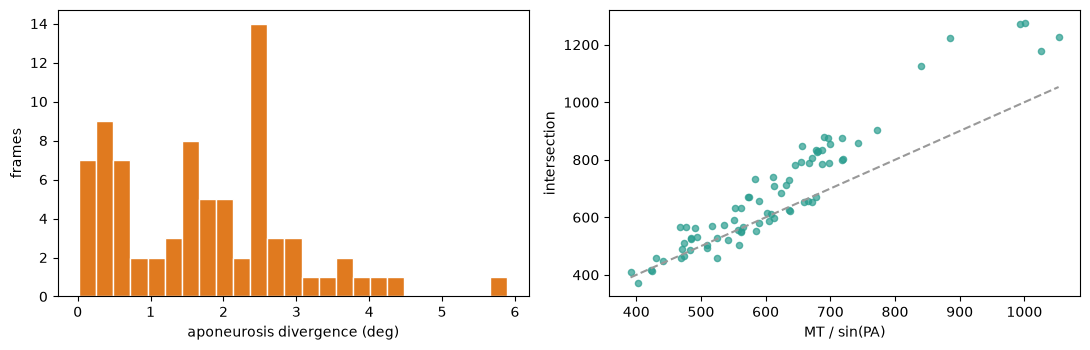

In [8]:
rel = (gt.fl_intersection - gt.fl_parallel).abs() / gt.fl_parallel
print(f"aponeurosis divergence : median {gt.divergence_deg.median():.2f} deg, p90 {gt.divergence_deg.quantile(.9):.2f} deg")
print(f"frames >2 deg from parallel: {(gt.divergence_deg > 2).mean():.0%}")
print(f"FL disagreement        : median {rel.median():.1%}, p90 {rel.quantile(.9):.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(gt.divergence_deg, bins=25, color="#e07a1f", edgecolor="white")
ax[0].set_xlabel("aponeurosis divergence (deg)"); ax[0].set_ylabel("frames")
ax[1].scatter(gt.fl_parallel, gt.fl_intersection, s=20, alpha=.7, color="#2a9d8f")
lim = [gt.fl_parallel.min(), gt.fl_parallel.max()]
ax[1].plot(lim, lim, "--", color="#999"); ax[1].set_xlabel("MT / sin(PA)"); ax[1].set_ylabel("intersection")
plt.tight_layout(); plt.show()

### 3.2 Are the orientation targets right?

The orientation supervision is *derived* from the fascicle masks with a
structure tensor, not annotated — so it needs its own check against an
independent estimator (per-segment principal axis).

In [9]:
from scipy import ndimage
from umud.data import load_pair, orientation_target
from umud.geometry import orientation_from_field

def pca_reference(mask):
    labels, n = ndimage.label(ndimage.binary_dilation(mask, np.ones((3, 3))), np.ones((3, 3)))
    vectors = []
    for k in range(1, n + 1):
        ys, xs = np.nonzero(labels == k)
        if ys.size < 12:
            continue
        cov = np.cov(np.stack([xs - xs.mean(), ys - ys.mean()]))
        if not np.all(np.isfinite(cov)):
            continue
        w, v = np.linalg.eigh(cov)
        if w[-1] <= 0 or w[-1] / max(w[0], 1e-9) < 3:
            continue
        a = np.arctan2(v[1, -1], v[0, -1])
        vectors.append((np.cos(2 * a), np.sin(2 * a), ys.size))
    if not vectors:
        return np.nan
    weights = [v[2] for v in vectors]
    c = np.average([v[0] for v in vectors], weights=weights)
    s = np.average([v[1] for v in vectors], weights=weights)
    return np.degrees(0.5 * np.arctan2(s, c))

random.seed(3)
diffs = []
for s in random.sample(fasc, 50):
    _, mask = load_pair(s, (512, 512))
    reference = pca_reference(mask)
    field = orientation_target(mask)
    estimated, _ = orientation_from_field(field[0], field[1], mask.astype(float), 1.0, 1.0)
    if not (np.isfinite(reference) and np.isfinite(estimated)):
        continue
    d = abs(reference - estimated)
    diffs.append(min(d, 180 - d))
diffs = np.array(diffs)
print(f"structure-tensor target vs per-segment PCA over {len(diffs)} frames:")
print(f"  median {np.median(diffs):.2f} deg | within 5 deg: {(diffs < 5).mean():.0%}")

structure-tensor target vs per-segment PCA over 50 frames:
  median 1.10 deg | within 5 deg: 100%


## 4. The hidden sequence structure

The competition ships 309 loose frames. They are not 309 independent scans.

In [10]:
groups = group_frames(test, cals)
sizes = pd.Series([g.size for g in groups]).value_counts().sort_index()
print(sizes.to_string())
runs = [g for g in groups if g.is_sequence]
print(f"\n{len(runs)} acquisition runs covering {sum(g.size for g in runs)} of {len(test)} frames")
print("example:", runs[0].names[0], "->", runs[0].names[-1])

1    174
5     27

27 acquisition runs covering 135 of 309 frames
example: IMG_00056.tif -> IMG_00060.tif


The grouping threshold is not a tuned parameter — the similarity distribution is
sharply bimodal and 0.995 sits in an empty gap.

![sequence structure](../docs/figures/sequence_structure.png)

## 5. Where this goes next

Training runs on Kaggle (`kaggle/train`), inference and evaluation on Kaggle
(`kaggle/infer`). Results, ablations and limitations are in
[`docs/REPORT.md`](../docs/REPORT.md).